<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula05a_linear_regressors_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## O que é Regressão?
- Problema de regressão: prever uma variável contínua a partir de uma ou mais variáveis explicativas.  
- Exemplo: prever o preço mediano de casas a partir de renda média, idade das casas, número médio de cômodos etc.
- Saída típica: $\hat{y} \in \mathbb{R}$ (não rótulos categóricos).  

## California Housing Dataset
- Dataset: California Housing, com 20.640 amostras e 8 atributos explicativos.   
- Atributos principais: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude.
- Alvo: valor mediano das casas em unidades de 100.000 dólares.


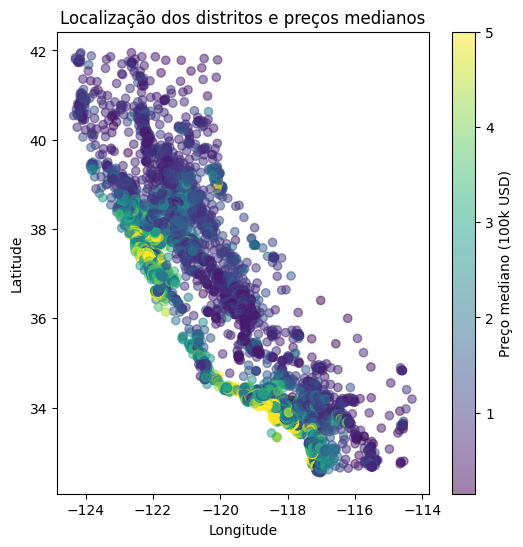

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

plt.figure(figsize=(6, 6))
plt.scatter(X[:, feature_names.index("Longitude")],
            X[:, feature_names.index("Latitude")],
            c=y, cmap="viridis", alpha=0.5)
plt.colorbar(label="Preço mediano (100k USD)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Localização dos distritos e preços medianos")
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_train_scaled)
mse = mean_squared_error(y_train, y_pred_lr)
print(f"Erro Quadrático Médio (MSE): {mse}")

Erro Quadrático Médio (MSE): 0.5179331255246699


In [6]:
y_pred = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Erro Quadrático Médio (MSE) no dataset de teste: {mse}")


Erro Quadrático Médio (MSE) no dataset de teste: 0.5558915986952442


In [13]:
from sklearn.metrics import root_mean_squared_error
def evaluate_model(model, X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = root_mean_squared_error(y_test, y_pred)
    print(f"RMSE: {rmse}, model: {model.__class__.__name__}")

evaluate_model(LinearRegression(), X, y)

RMSE: 0.7455813830127763, model: LinearRegression


In [14]:
from sklearn.linear_model import BayesianRidge
evaluate_model(BayesianRidge(), X, y)

RMSE: 0.7455407067722319, model: BayesianRidge


In [15]:
from sklearn.linear_model import SGDRegressor
evaluate_model(SGDRegressor(), X, y)

RMSE: 0.7505151088049073, model: SGDRegressor


In [16]:
from sklearn.svm import LinearSVR
evaluate_model(LinearSVR(), X, y)

RMSE: 0.7649662846843651, model: LinearSVR


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [17]:
from sklearn.neighbors import KNeighborsRegressor
evaluate_model(KNeighborsRegressor(), X, y)

RMSE: 0.6575877238850522, model: KNeighborsRegressor


In [18]:
from sklearn.tree import DecisionTreeRegressor
evaluate_model(DecisionTreeRegressor(), X, y)

RMSE: 0.7074417808033302, model: DecisionTreeRegressor


In [19]:
from sklearn.ensemble import RandomForestRegressor
evaluate_model(RandomForestRegressor(), X, y)

RMSE: 0.5048375202938954, model: RandomForestRegressor


In [20]:
from sklearn.neural_network import MLPRegressor
evaluate_model(MLPRegressor(), X, y)

RMSE: 0.5475907457545783, model: MLPRegressor
